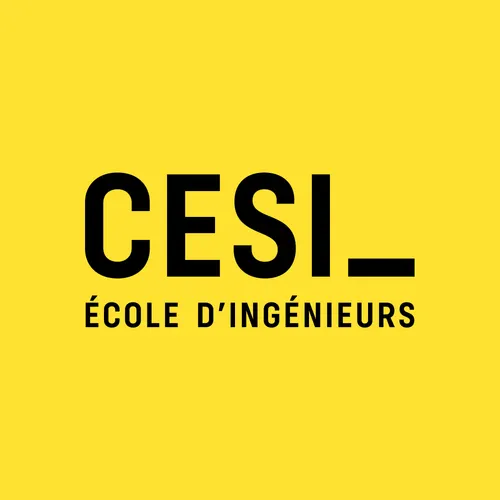

# Deliverable 1
## <center>  Diabetes prediction project


### Group 4:
- Jeniffer S
- Hawiyana AB
- Adnan CJ

# Context

We have been tasked to build a binary classification model to predict diabetes risk using CDC BRFSS 2015 survey data. The work follows an MLOps approach and is organized in three sprints.

During this deliverable, we'll focus on data preparation i.e the foundational phase that ensures raw data is cleaned, understood, and transformed into a format suitable for modeling.

# Objectives

The goal of this deliverable is to transform the raw dataset into a clean, well-documented, and ready-to-use state for the modeling phase. By following the below plan:


1. ***Load & Understand***	Import the dataset, examine its structure, shape, and target distribution
2. ***Clean the Data***	Remove duplicate records and handle any missing values
3. ***Separate Variables***	Distinguish target variable (Diabetes_012) from explanatory features
4. ***Verify Data Types***	Ensure all variables are correctly typed (binary, numerical, categorical)
5. ***Perform EDA***	Conduct quantitative (descriptive stats, correlations) and qualitative (visualizations) exploratory analysis
6. ***Normalize Features***	Apply standardization to numerical features for models that require scaling
7. ***Split the Data***	Divide dataset into training, validation, and test sets
8. ***Save Cleaned Data***	Export cleaned and normalized versions for use in Sprint 2

# Importing

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Loading data

In [149]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (253680, 22)

First 5 rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       

# Initial understanding of data

In [150]:
print("\nColumn names and data types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

print("\nTarget distribution (Diabetes_012):")
print(df['Diabetes_012'].value_counts().sort_index())


Column names and data types:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012     

In [151]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


array([[<Axes: title={'center': 'Diabetes_012'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title={'c

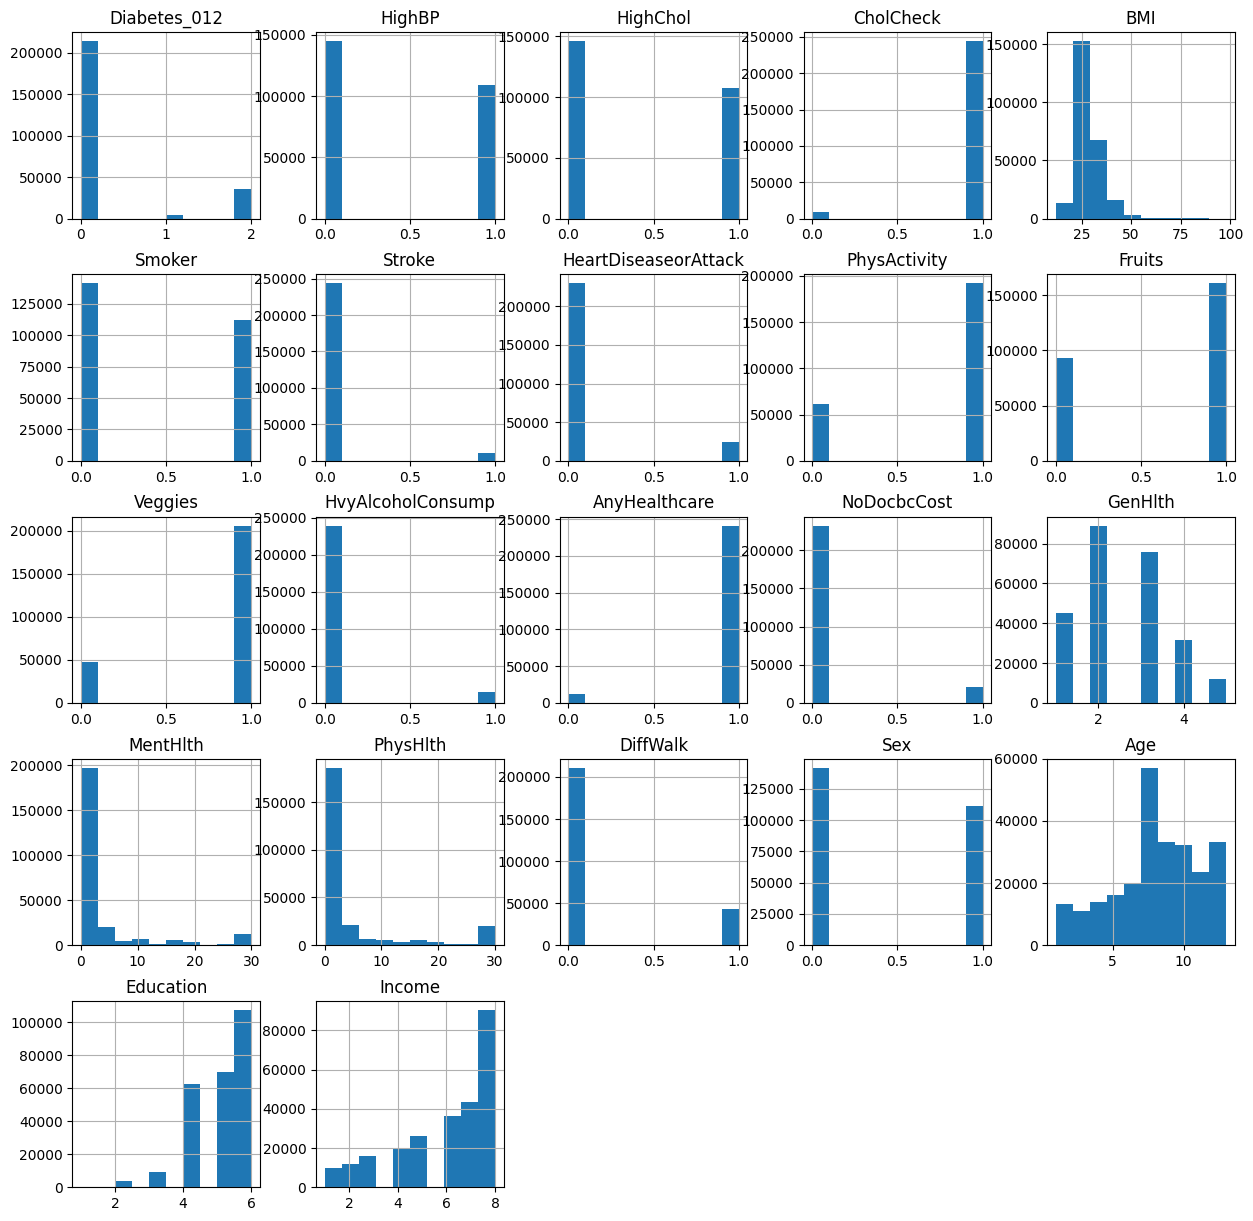

In [152]:
df.hist(figsize=(15, 15))

# Check for duplicates and cleaning of data

In [153]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows: 23,899
Duplicates removed. New shape: (229781, 22)


## Check missing values

In [154]:
print(f"\nMissing values per column:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found!")


Missing values per column:
No missing values found!


## Creation of a binary target i.e classifying data

The Diabetes Binary variable transforms the original three-class target into a binary format by grouping prediabetes $1$ and no diabetes $0$ into a single positive class *0*, while keeping diabetes $1$ as the positive class *1*.

In [155]:
df['Diabetes_binary'] = (df['Diabetes_012'] == 2).astype(int)

print(f"Diabetes_binary distribution:")
print(f"  0 (No Diabetes or Prediabetes): {(df['Diabetes_binary']==0).sum():,}")
print(f"  1 (Diabetes): {(df['Diabetes_binary']==1).sum():,}")

Diabetes_binary distribution:
  0 (No Diabetes or Prediabetes): 194,684
  1 (Diabetes): 35,097


# Quantitative *Analysis*
## Descriptive statistics

In [156]:
print("\nDescriptive Statistics (Numerical Features):")
print(df.describe())


Descriptive Statistics (Numerical Features):
        Diabetes_012         HighBP       HighChol      CholCheck  \
count  229781.000000  229781.000000  229781.000000  229781.000000   
mean        0.325627       0.454441       0.441760       0.959535   
std         0.724623       0.497921       0.496598       0.197047   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       1.000000       1.000000       1.000000   
max         2.000000       1.000000       1.000000       1.000000   

                BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  229781.00000  229781.000000  229781.000000         229781.000000   
mean       28.68567       0.465661       0.044756              0.103216   
std         6.78636       0.498821       0.206767              0.304241   
min        12.00000       0.0000

## Correlation with the target

In [157]:
print("\nCorrelation with Diabetes_binary:")
correlations = df.corr()['Diabetes_binary'].sort_values(ascending=False)
print(correlations)



Correlation with Diabetes_binary:
Diabetes_binary         1.000000
Diabetes_012            0.981094
GenHlth                 0.277060
HighBP                  0.254029
DiffWalk                0.205511
BMI                     0.205125
HighChol                0.194683
Age                     0.176953
HeartDiseaseorAttack    0.168336
PhysHlth                0.156446
Stroke                  0.099301
CholCheck               0.072396
MentHlth                0.054385
Smoker                  0.045588
Sex                     0.032574
AnyHealthcare           0.025206
NoDocbcCost             0.020206
Fruits                 -0.025043
Veggies                -0.041956
HvyAlcoholConsump      -0.065795
PhysActivity           -0.100663
Education              -0.102969
Income                 -0.140934
Name: Diabetes_binary, dtype: float64


# Qualitative Analysis
## Target distribution plot

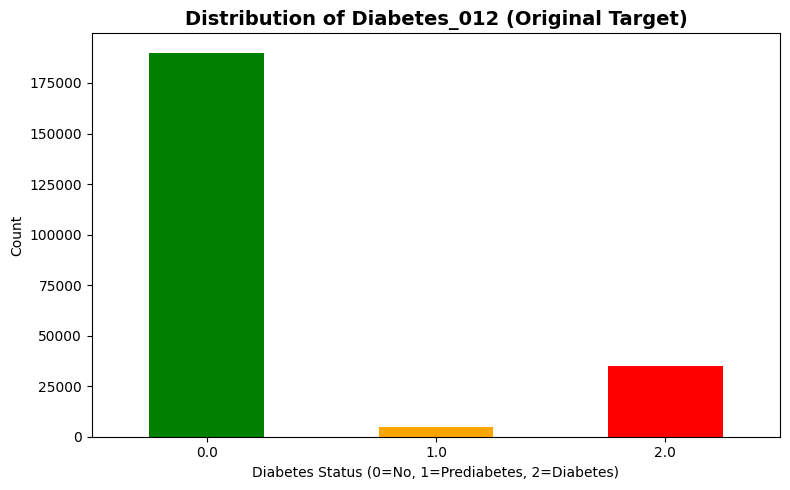

In [158]:
plt.figure(figsize=(8, 5))
df['Diabetes_012'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution of Diabetes_012 (Original Target)', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status (0=No, 1=Prediabetes, 2=Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation heatmap

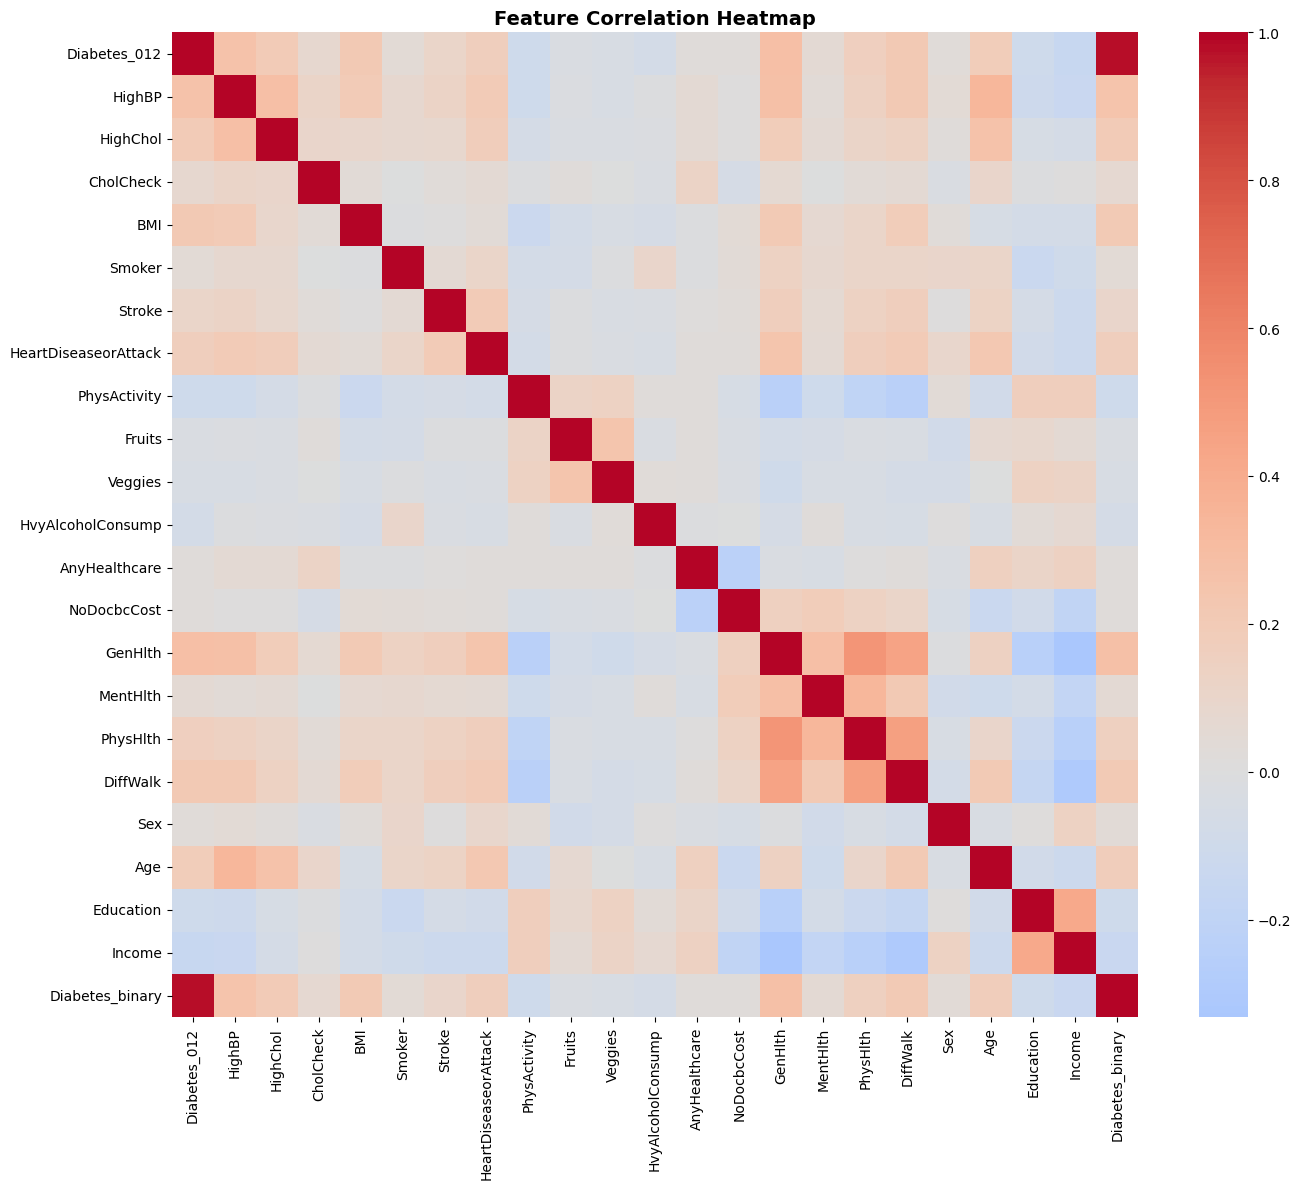

In [159]:
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### BMI vs diabetes status

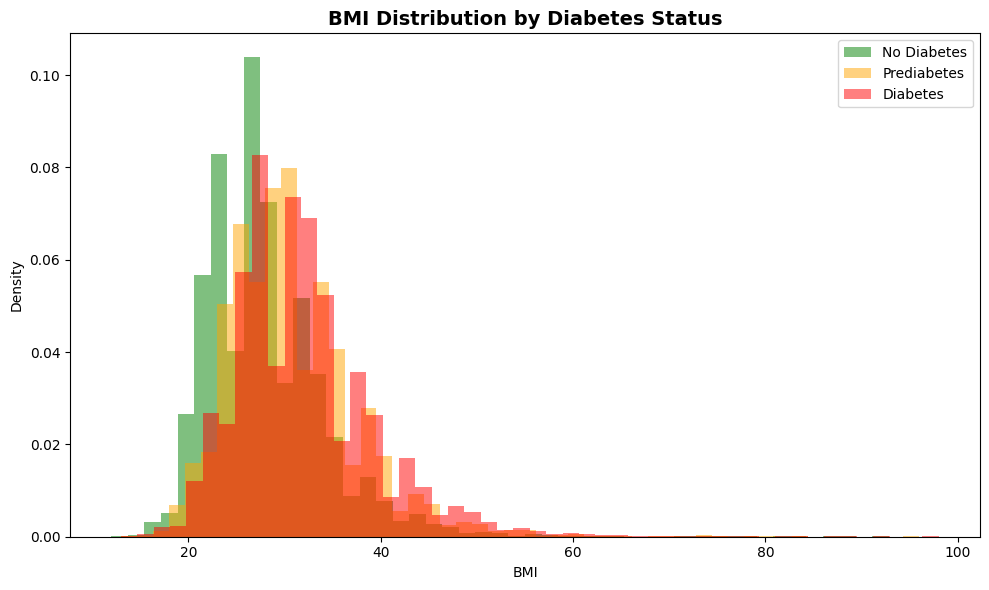

In [160]:
plt.figure(figsize=(10, 6))
for status, color, label in [(0, 'green', 'No Diabetes'), (1, 'orange', 'Prediabetes'), (2, 'red', 'Diabetes')]:
    subset = df[df['Diabetes_012'] == status]
    plt.hist(subset['BMI'], bins=50, alpha=0.5, color=color, label=label, density=True)
plt.title('BMI Distribution by Diabetes Status', fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('eda_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Age distribution

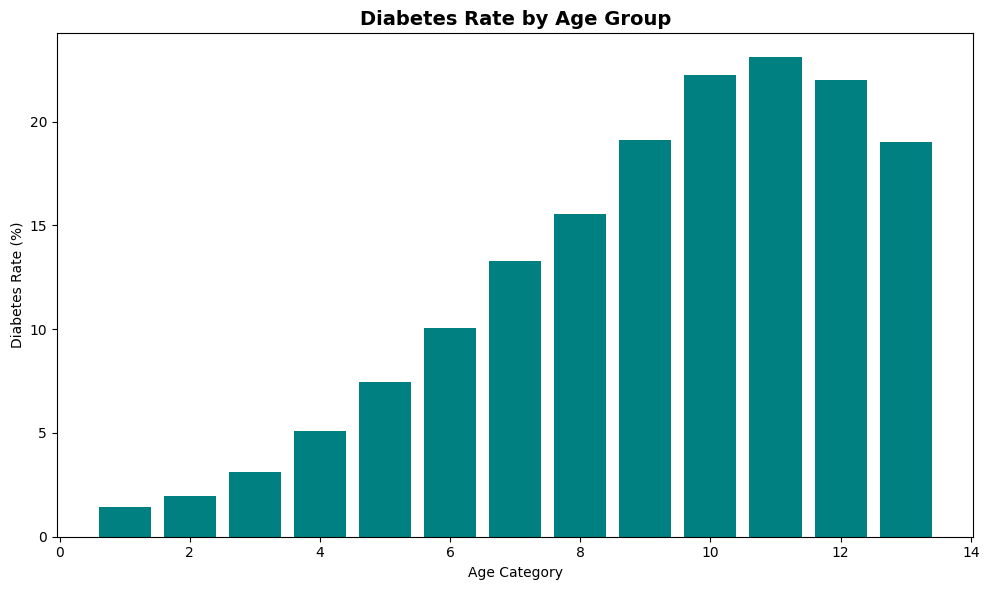

In [161]:
plt.figure(figsize=(10, 6))
age_by_diabetes = df.groupby('Age')['Diabetes_binary'].mean() * 100
plt.bar(age_by_diabetes.index, age_by_diabetes.values, color='teal')
plt.title('Diabetes Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Diabetes Rate (%)')
plt.tight_layout()
plt.savefig('eda_age_diabetes_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Variable typing

In [162]:
binary_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

numerical_vars = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Income', 'Education', 'GenHlth']

all_vars = binary_vars + numerical_vars + ['Diabetes_012', 'Diabetes_binary']
print(f"\nAll columns accounted for: {set(df.columns) == set(all_vars)}")


All columns accounted for: True


# Normalisation

In [163]:
df_normalized = df.copy()

In [164]:
scaler = StandardScaler()
df_normalized[numerical_vars] = scaler.fit_transform(df[numerical_vars])

print(f"Applied StandardScaler to: {numerical_vars}")
print("\nNormalized statistics (BMI after scaling):")
print(df_normalized['BMI'].describe())

Applied StandardScaler to: ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Income', 'Education', 'GenHlth']

Normalized statistics (BMI after scaling):
count    2.297810e+05
mean    -1.935755e-16
std      1.000002e+00
min     -2.458712e+00
25%     -6.904556e-01
50%     -2.483915e-01
75%      4.883821e-01
max      1.021379e+01
Name: BMI, dtype: float64


# Saving cleaned dataset

In [165]:
df.to_csv(r'/content/diabetes_cleaned.csv', index=False)
print("dataset saved")

dataset saved


In [166]:
df_normalized.to_csv(r'/content/diabetes_cleaned_normalized.csv', index=False)
print("normalised dataset saved")

normalised dataset saved


# Target vs explanatory variables

In [167]:
X = df.drop(['Diabetes_012', 'Diabetes_binary'], axis=1)
y = df['Diabetes_binary']

print(f"\nFeatures: {X.shape[1]} columns")
print(f"Feature names: {X.columns.tolist()}")


Features: 21 columns
Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


# Sample data

## Stratified sample

In [168]:
sample_size = 10000
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=sample_size,
    random_state=42,
    stratify=y
)

print(f"\nSampled {sample_size:,} records for training")


Sampled 10,000 records for training


## Split data

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 8000 samples
Test set: 2000 samples


# Conclusion
The deliverable has been successfully transformed raw CDC BRFSS 2015 survey data into a clean, normalized, and well-understood dataset ready for modeling. All required tasks were completed with respect to the constraints.

The insights gained during exploratory analysis will directly inform modeling decisions in the next phase, ensuring that the final model is both performant and interpretable.